# Handling Missing Values

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
missing_values_demo_df = pd.read_csv('missing_values_demo.csv')

In [3]:
missing_values_demo_df.head()

,Name,Designation,Age,Experience_Years,Salary
0,Jane Smith,Team Lead,58.0,20,NaN
1,Michael Brown,Jr. Developer,48.0,19,59303.0
2,Emily Williams,Jr. Data Analyst,34.0,6,66997.0
3,Jane Anderson,Team Lead,27.0,7,128386.0
4,Jane Taylor,Sr. Data Analyst,40.0,10,110965.0


In [4]:
missing_values_demo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               946 non-null    float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            923 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


As can be seen above, Age and Salary Columns have some Missing Values.

##### Finding Number of Missing Values and Percentage of Missing Values:

In [5]:
# Number of Missing Values:

print(missing_values_demo_df.isna().sum())

Name                 0
Designation          0
Age                 54
Experience_Years     0
Salary              77
dtype: int64


- Age has 54 rows with Missing Values.
- Salary has 77 rows with missing Values.

In [6]:
# Percentage of Missing Values:

print((missing_values_demo_df.isna().sum()) / len(missing_values_demo_df) * 100)

Name                0.0
Designation         0.0
Age                 5.4
Experience_Years    0.0
Salary              7.7
dtype: float64


- Age Columns has 5.4% rows with Missing Values.
- Salary Column has 7.7% rows with Missing Values.

### Techniques for Handling Missing Values:

#### 1) Deletion of Columns / Rows:

In [7]:
# Deleting Columns with Missing Values:

new_df = missing_values_demo_df.dropna(axis= 1)

In [8]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Name              1000 non-null   object
 1   Designation       1000 non-null   object
 2   Experience_Years  1000 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 23.6+ KB


- Very Faulty Approch to Handle Missing Values.
- Loss of Information as Columns are Now Not Available for Analysis / Modelling.
- Should be Used Very Cautiosly only when Column has a Lot of Missing Values (Percentage of Missing Values is more than 50%).

In [9]:
# Deleting Rows with Missing Values:

new_df = missing_values_demo_df.dropna(axis= 0)

In [10]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 872 entries, 1 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              872 non-null    object 
 1   Designation       872 non-null    object 
 2   Age               872 non-null    float64
 3   Experience_Years  872 non-null    int64  
 4   Salary            872 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 40.9+ KB


- Better Approch Than Deleting Columns with Missing Values.
- There is still Loss of Information (128 rows from 1000 before deletion, 12.8% loss of Information), but columns are still Available for Analysis.

#### 2) Filling Missing Values:

##### 1) Mean Imputation:
Replacing Missing Values in Age and Salary Columns with Mean of the Column.

In [11]:
new_df = missing_values_demo_df.copy()

In [12]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               946 non-null    float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            923 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


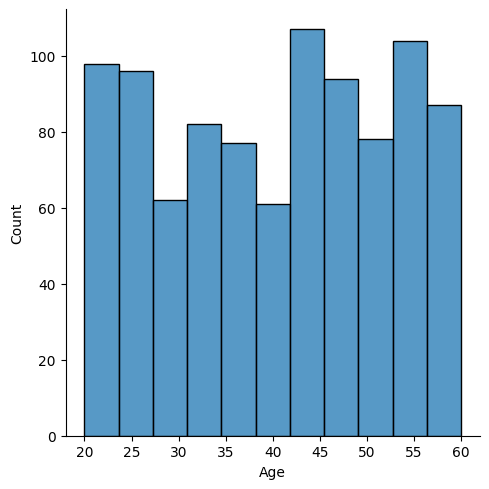

In [13]:
# Distribution of Age:

sns.displot(data= new_df, x= 'Age')
plt.show()

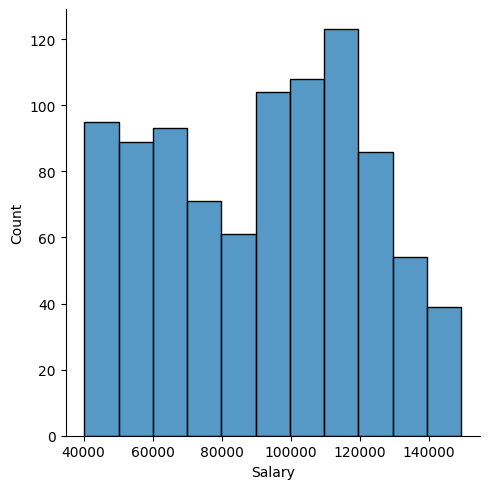

In [14]:
# Distribution of Salary:

sns.displot(data= new_df, x= 'Salary')
plt.show()

In [15]:
print(new_df['Age'].mean())
print(new_df['Salary'].mean())

40.32663847780127
91714.85373781149


In [16]:
new_df['Age'] = new_df['Age'].fillna(round(new_df['Age'].mean()))
new_df['Salary'] = new_df['Salary'].fillna(round(new_df['Salary'].mean()))

In [17]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               1000 non-null   float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            1000 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


- This approach works better when Data is Normally Distributed (or close to it).
- Mean Imputation is prone to Outliers existence in data.
- Shrinks Variance of Data as all more values are closer to the Mean Value after Imputation.

##### 2) Median Imputation:
Replacing Missing Values in Age and Salary Columns with Median of the Column.

In [18]:
new_df = missing_values_demo_df.copy()

In [19]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               946 non-null    float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            923 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


In [20]:
# Medians of Age and Salary Columns:

print(new_df['Age'].median())
print(new_df['Salary'].median())

41.0
94679.0


In [21]:
new_df['Age'] = new_df['Age'].fillna(new_df['Age'].median())
new_df['Salary'] = new_df['Salary'].fillna(new_df['Salary'].median())

In [22]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               1000 non-null   float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            1000 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


- This Approach is More Robust to Outliers than Mean Imputation.
- Works better even when Data is Not Normally Distributed / Skewed.

##### Mode Imputation:
Replacing Missing Values in Age column with Mode of the Column.

In [23]:
new_df = missing_values_demo_df.copy()

In [24]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               946 non-null    float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            923 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


In [25]:
# Mode of Age Column:

new_df['Age'].mode()

0    52.0
Name: Age, dtype: float64

In [26]:
new_df['Age'] = new_df['Age'].fillna(new_df['Age'].mode()[0])

In [27]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               1000 non-null   float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            923 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


- Mode Imputation is more commonly used when Data is Categorical or for Discrete-like Numerical Data.
- Is rarely used for Continous Data like Salary.

##### 4) Constant Imputation:
Replacing Missing Values with a Constant, A value that does not occur in the Data Naturally (Age with -1 or Salary with -1).

In [28]:
new_df = missing_values_demo_df.copy()

In [29]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               946 non-null    float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            923 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


In [30]:
new_df['Age'] = new_df['Age'].fillna(-1)
new_df['Salary'] = new_df['Salary'].fillna(-1)

In [31]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               1000 non-null   float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            1000 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


- Useful to mark missing as a special value for downstream models.
- Should be Used with Caution.

##### 5) Forward / Backward Imputation:
Use previous value (ffill) or next value (bfill) to fill gaps (ordered by index).

In [32]:
new_df = missing_values_demo_df.copy()

In [33]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               946 non-null    float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            923 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


In [34]:
new_df['Age'] = new_df['Age'].ffill()
new_df['Salary'] = new_df['Salary'].bfill()

In [35]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               1000 non-null   float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            1000 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


- This approach works Better when Rows are time Ordered (Time Series) or Meaningfully Ordered.

##### 6) Group Wise Mean / Median / Mode Imputation:
In this approach we Undertand the Data and Find Groups within it to which each row with Missing Values belongs and Use Mean / Median / Mode of that group to fill the missing value.

e.g. To fill Missing Value in Salary, we find Employees with same Designation and around Same Experience years to make groups.

In [46]:
new_df = missing_values_demo_df.copy()

In [47]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               946 non-null    float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            923 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


In [48]:
new_df.head()

,Name,Designation,Age,Experience_Years,Salary
0,Jane Smith,Team Lead,58.0,20,NaN
1,Michael Brown,Jr. Developer,48.0,19,59303.0
2,Emily Williams,Jr. Data Analyst,34.0,6,66997.0
3,Jane Anderson,Team Lead,27.0,7,128386.0
4,Jane Taylor,Sr. Data Analyst,40.0,10,110965.0


In [49]:
print(new_df['Designation'].unique())
print(new_df['Experience_Years'].unique())

['Team Lead' 'Jr. Developer' 'Jr. Data Analyst' 'Sr. Data Analyst'
 'Sr. Developer' 'Manager']
[20 19  6  7 10 11 12  4 22 31 36 25  1  3  8 23  0 18  9 17  5 21 24 13
 26 15 28 34  2 32 16 14 33 30 27 29 37 38 35 40]


- We can make groups here by using Designation and Range of Experience Years(Years is Discrete Numeric Variable, So it's better to use range of years rather than a single year in groups).

In [50]:
# Function to Create Groups in Experience Years:

def exp_years_groups(years):
    """
    Takes in Experience Years and Retruns Label of Experience Years Range
    e.g 6 years = '5-10 Years'
    """

    if years <= 5:
        return '0-5 Years'
    elif years > 5 and years <= 10:
        return '6-10 Years'
    elif years > 10 and years <= 15:
        return '11-15 Years'
    elif years > 15 and years <= 20:
        return '16-20 Years'
    elif years > 20 and years < 25:
        return '21-25 Years'
    else: return '>25 Years'

In [51]:
# Creating New Column with Range of Experience Years:
new_df['Experience_Range'] = new_df['Experience_Years'].apply(exp_years_groups)
new_df.head()

,Name,Designation,Age,Experience_Years,Salary,Experience_Range
0,Jane Smith,Team Lead,58.0,20,NaN,16-20 Years
1,Michael Brown,Jr. Developer,48.0,19,59303.0,16-20 Years
2,Emily Williams,Jr. Data Analyst,34.0,6,66997.0,6-10 Years
3,Jane Anderson,Team Lead,27.0,7,128386.0,6-10 Years
4,Jane Taylor,Sr. Data Analyst,40.0,10,110965.0,6-10 Years


In [52]:
# Salary Medians of Groups Based on Designations and Experience Range:

new_df.groupby(['Designation', 'Experience_Range'])['Salary'].median()

Designation       Experience_Range
Jr. Data Analyst  0-5 Years            53565.0
                  11-15 Years          57518.0
                  16-20 Years          61017.0
                  21-25 Years          50874.0
                  6-10 Years           57128.0
                  >25 Years            51962.0
Jr. Developer     0-5 Years            61631.5
                  11-15 Years          54735.5
                  16-20 Years          65121.0
                  21-25 Years          58372.0
                  6-10 Years           61407.5
                  >25 Years            55569.0
Manager           0-5 Years           129487.0
                  11-15 Years         118707.5
                  16-20 Years         113543.0
                  21-25 Years         128304.0
                  6-10 Years          118691.5
                  >25 Years           118420.0
Sr. Data Analyst  0-5 Years            96439.0
                  11-15 Years          92095.0
                  16-20 Y

In [53]:
# Filling Missing Values in Salary with Median of Groups Based on Designation and Experience Range:

new_df['Salary'] = new_df.groupby(['Designation', 'Experience_Range'])['Salary'].transform(lambda s : s.fillna(s.median()))

In [54]:
new_df.head()

,Name,Designation,Age,Experience_Years,Salary,Experience_Range
0,Jane Smith,Team Lead,58.0,20,111074.0,16-20 Years
1,Michael Brown,Jr. Developer,48.0,19,59303.0,16-20 Years
2,Emily Williams,Jr. Data Analyst,34.0,6,66997.0,6-10 Years
3,Jane Anderson,Team Lead,27.0,7,128386.0,6-10 Years
4,Jane Taylor,Sr. Data Analyst,40.0,10,110965.0,6-10 Years


In [55]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               946 non-null    float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            1000 non-null   float64
 5   Experience_Range  1000 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 47.0+ KB


- This Approach is more accurate than a simple global mean or median imputation because it considers the context of the employee's role and experience level. Salary is very likely to be correlated with both of these factors.
- Grouping helps to smooth out the noise and outliers that might be present in the data, leading to a more stable imputation.
- We can make groups more and more detailed (Using More Columns highly correalted with Salary) to get closer to Truth.

##### 7) Linear Interpolation:

Interpolation technique to use:

- ‘linear’: Ignore the index and treat the values as equally spaced. This is the only method supported on MultiIndexes.

- ‘time’: Works on daily and higher resolution data to interpolate given length of interval.

- ‘index’, ‘values’: use the actual numerical values of the index.

- ‘pad’: Fill in NaNs using existing values.

- ‘nearest’, ‘zero’, ‘slinear’, ‘quadratic’, ‘cubic’, ‘barycentric’, ‘polynomial’: Passed to scipy.interpolate.interp1d, whereas ‘spline’ is passed to scipy.interpolate.UnivariateSpline. These methods use the numerical values of the index. Both ‘polynomial’ and ‘spline’ require that you also specify an order (int), e.g. df.interpolate(method='polynomial', order=5). Note that, slinear method in Pandas refers to the Scipy first order spline instead of Pandas first order spline.

- ‘krogh’, ‘piecewise_polynomial’, ‘spline’, ‘pchip’, ‘akima’, ‘cubicspline’: Wrappers around the SciPy interpolation methods of similar names. See Notes.

- ‘from_derivatives’: Refers to scipy.interpolate.BPoly.from_derivatives.

In [61]:
new_df = missing_values_demo_df.copy()

In [62]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               946 non-null    float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            923 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


In [63]:
new_df['Age'] = new_df['Age'].interpolate(method= 'linear')
new_df['Salary'] = new_df['Salary'].interpolate(method= 'linear')

In [64]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   Designation       1000 non-null   object 
 2   Age               1000 non-null   float64
 3   Experience_Years  1000 non-null   int64  
 4   Salary            999 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


### Some Advanced Methods for Filling Missing Values:

##### 1) KNN Imputation (sklearn.impute.KNNImputer):

Uses similar rows to estimate missing values; works well when similar rows exist.

##### 2) Iterative Imputer (MICE-like) (sklearn.impute.IterativeImputer):

Multivariate iterative imputation using other variables as predictors (looped regression).

Usually one of the better general-purpose methods for numeric imputation.

##### 3) Regression-based imputation (RandomForestRegressor):

Powerful when you have good predictive features.

##### 4) Impute + Missingness Indicators:

Create an indicator column (Age_was_missing, Salary_was_missing) while using imputation.

Good practice: allows models to learn that a value was imputed.